# Assignment 5 - Task 1: LLM Decoding Strategy Analysis

**Course:** EE5102/CS6302 - Advanced Topics in Machine Learning  
**Task:** Comparative analysis of Greedy Search, Beam Search, Top-K Sampling, and Top-P (Nucleus) Sampling.

**Objective:**  
To investigate the trade-offs between generation quality and output diversity using the `SmolLM2-135M-SFT-Only` model.

**Metrics:**
1.  **Diversity:** Distinct-N (Unique N-grams / Total N-grams).
2.  **Quality:** Scalar score from an external Reward Model.

In [1]:
# Install necessary libraries (uncomment if needed)
# !pip install transformers torch accelerate numpy matplotlib seaborn

import os

# --- CRITICAL FIXES ---
# 1. Disable the Rust-based downloader that caused the 70-minute loop/crash
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0" 

# 2. Disable Tokenizer Parallelism to fix "Too many open files" crash
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- CONFIGURATION ---
MODEL_NAME = "HuggingFaceTB/smollm2-135M-SFT-Only" 
REWARD_MODEL_NAME = "OpenAssistant/reward-model-deberta-v3-large-v2" 
MAX_NEW_TOKENS = 50
SEED = 42

# Set seed for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cpu


## 1. Model Loading
We load the SFT baseline model (`SmolLM2-135M-SFT-Only`) for text generation and a separate Reward Model to evaluate the alignment/quality of the outputs.

In [2]:
print(f"Loading Model: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Ensure pad token is set for batching (if needed later), though we do manual loops
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"Loading Reward Model: {REWARD_MODEL_NAME}...")
rm_tokenizer = AutoTokenizer.from_pretrained(REWARD_MODEL_NAME)
reward_model = AutoModelForSequenceClassification.from_pretrained(REWARD_MODEL_NAME).to(device)
reward_model.eval()

print("Models loaded successfully.")

# Helper functions
def prepare_inputs(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    return inputs['input_ids']

def is_eos(token_id):
    return token_id == tokenizer.eos_token_id

Loading Model: HuggingFaceTB/smollm2-135M-SFT-Only...
Loading Reward Model: OpenAssistant/reward-model-deberta-v3-large-v2...


pytorch_model.bin:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Models loaded successfully.


## 2. Evaluation Metrics Implementation
We implement the two core metrics required:
1.  **Distinct-N:** Calculated as $\frac{\text{unique N-grams}}{\text{total N-grams}}$.
2.  **Reward Score:** A forward pass through the Reward Model to get a scalar quality score.

In [3]:
def calculate_distinct_n(texts, n=2):
    """
    Calculates Distinct-N metric to measure lexical diversity.
    """
    unique_ngrams = set()
    total_ngrams = 0
    
    for text in texts:
        words = text.split()
        if len(words) < n:
            continue
        # Generate n-grams
        ngrams = [tuple(words[i:i+n]) for i in range(len(words)-n+1)]
        unique_ngrams.update(ngrams)
        total_ngrams += len(ngrams)
    
    if total_ngrams == 0:
        return 0.0
    
    return len(unique_ngrams) / total_ngrams

def get_reward_score(prompts, responses):
    """
    Computes scalar reward score. 
    """
    scores = []
    with torch.no_grad():
        for p, r in zip(prompts, responses):
            # The RM expects "text_a" (prompt) and "text_b" (response)
            inputs = rm_tokenizer(p, r, return_tensors='pt', truncation=True, max_length=512).to(device)
            score = reward_model(**inputs).logits[0].cpu().detach().item()
            scores.append(score)
    return np.mean(scores)

## 3. Manual Implementation of Decoding Strategies
We manually implement the decoding loops to demonstrate mechanistic understanding.

### 3.1 Greedy Search
Always picks the token with the max probability.

In [4]:
def greedy_search(prompt, max_new_tokens=50):
    input_ids = prepare_inputs(prompt)
    
    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
            next_token_logits = outputs.logits[:, -1, :]
            
            # Greedy: Argmax
            next_token = torch.argmax(next_token_logits, dim=-1).unsqueeze(-1)
            input_ids = torch.cat([input_ids, next_token], dim=-1)
            
            if is_eos(next_token.item()):
                break
                
    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

### 3.2 Beam Search
Maintains `beam_width` sequences. At every step, it expands all beams, ranks the $B \times V$ candidates, and keeps the top $B$.

In [5]:
def beam_search(prompt, beam_width=3, max_new_tokens=50):
    input_ids = prepare_inputs(prompt)
    # Beams: List of (sequence_tensor, cumulative_score)
    beams = [(input_ids, 0.0)]
    
    for _ in range(max_new_tokens):
        candidates = []
        # Flag to stop if all beams hit EOS (simplified)
        all_finished = True
        
        for seq, score in beams:
            # Check if this beam has finished
            if is_eos(seq[0, -1].item()):
                candidates.append((seq, score))
                continue
            
            all_finished = False
            
            with torch.no_grad():
                outputs = model(seq)
                next_token_logits = outputs.logits[:, -1, :]
                # Use Log Softmax for numerical stability in summation
                next_token_log_probs = F.log_softmax(next_token_logits, dim=-1)
                
                # Get top B candidates for *this* beam to reduce search space
                top_probs, top_ids = torch.topk(next_token_log_probs, beam_width)
                
                for i in range(beam_width):
                    token_id = top_ids[0, i].unsqueeze(0).unsqueeze(0)
                    token_score = top_probs[0, i].item()
                    new_seq = torch.cat([seq, token_id], dim=-1)
                    new_score = score + token_score # Add log probs
                    candidates.append((new_seq, new_score))
        
        if all_finished:
            break
            
        # Sort all candidates from all beams by score, keep top B
        ordered = sorted(candidates, key=lambda x: x[1], reverse=True)
        beams = ordered[:beam_width]
        
    return tokenizer.decode(beams[0][0][0], skip_special_tokens=True)

### 3.3 Top-K Sampling
Restricts sampling to the $K$ most likely tokens.

In [6]:
def top_k_sampling(prompt, k=50, temperature=1.0, max_new_tokens=50):
    input_ids = prepare_inputs(prompt)
    
    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :]
            
            # 1. Apply Temperature
            logits = logits / temperature
            
            # 2. Filter Top-K
            top_k_logits, top_k_indices = torch.topk(logits, k)
            filtered_logits = torch.full_like(logits, float('-inf'))
            filtered_logits.scatter_(1, top_k_indices, top_k_logits)
            
            # 3. Softmax & Sample
            probs = F.softmax(filtered_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            input_ids = torch.cat([input_ids, next_token], dim=-1)
            if is_eos(next_token.item()):
                break
                
    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

### 3.4 Top-P (Nucleus) Sampling
Selects the smallest set of tokens whose cumulative probability exceeds $P$.

In [7]:
def top_p_sampling(prompt, p=0.9, temperature=1.0, max_new_tokens=50):
    input_ids = prepare_inputs(prompt)
    
    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :]
            
            # 1. Apply Temperature
            logits = logits / temperature
            
            # 2. Sort descending
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            
            # 3. Masking
            # Remove tokens with cumulative probability above the threshold
            sorted_indices_to_remove = cumulative_probs > p
            # Shift the indices to the right to keep also the first token above the threshold
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0
            
            # Scatter sorted masks back to original positions
            indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
            logits[indices_to_remove] = float('-inf')
            
            # 4. Sample
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            input_ids = torch.cat([input_ids, next_token], dim=-1)
            if is_eos(next_token.item()):
                break
                
    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

## 4. Experimental Setup & Execution
We define 10 open-ended prompts to test diversity and quality.

**Experiments:**
1.  **Across-Prompt:** We run all strategies on all prompts. For Top-K/P, we sweep temperatures $[0.2, 0.5, 0.8, 1.0, 1.2]$.
2.  **Within-Prompt:** We fix $T=0.8$ and one prompt, generate $N=10$ samples, and check diversity collapse.

In [8]:
test_prompts = [
    "Write a short story about a robot who wants to become a chef.",
    "Explain the concept of quantum entanglement to a five-year-old.",
    "List three creative ways to use a paperclip.",
    "Compose a poem about the first snowfall of winter.",
    "Describe a futuristic city where cars are obsolete.",
    "Provide a step-by-step guide on how to make the perfect cup of coffee.",
    "Write a dialogue between a cat and a dog discussing their owners.",
    "What are the pros and cons of living on Mars?",
    "Invent a new holiday and describe how it is celebrated.",
    "Write a letter to your future self 10 years from now."
]

results = []
temperatures = [0.2, 0.5, 0.8, 1.0, 1.2]

print("--- Experiment 1: Across-Prompt Diversity & Quality Trade-off ---")

# 1. Deterministic Baselines
print("Running Greedy...")
greedy_res = [greedy_search(p) for p in tqdm(test_prompts)]
results.append({
    "Strategy": "Greedy", "Temp": 0,
    "Distinct-2": calculate_distinct_n(greedy_res, 2),
    "Quality": get_reward_score(test_prompts, greedy_res)
})

print("Running Beam (B=3)...")
beam_res = [beam_search(p, beam_width=3) for p in tqdm(test_prompts)]
results.append({
    "Strategy": "Beam", "Temp": 0,
    "Distinct-2": calculate_distinct_n(beam_res, 2),
    "Quality": get_reward_score(test_prompts, beam_res)
})

# 2. Stochastic Strategies
print("Running Stochastic Sweeps...")
for t in temperatures:
    # Top-K
    k_res = [top_k_sampling(p, k=50, temperature=t) for p in test_prompts]
    results.append({
        "Strategy": "Top-K", "Temp": t,
        "Distinct-2": calculate_distinct_n(k_res, 2),
        "Quality": get_reward_score(test_prompts, k_res)
    })
    
    # Top-P
    p_res = [top_p_sampling(p, p=0.9, temperature=t) for p in test_prompts]
    results.append({
        "Strategy": "Top-P", "Temp": t,
        "Distinct-2": calculate_distinct_n(p_res, 2),
        "Quality": get_reward_score(test_prompts, p_res)
    })

df_results = pd.DataFrame(results)
print("\nExperiment 1 Results:")
print(df_results)

--- Experiment 1: Across-Prompt Diversity & Quality Trade-off ---
Running Greedy...


 30%|███       | 3/10 [00:01<00:02,  3.42it/s]

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

100%|██████████| 10/10 [00:26<00:00,  2.69s/it]


Running Beam (B=3)...


100%|██████████| 10/10 [01:39<00:00,  9.92s/it]


Running Stochastic Sweeps...

Experiment 1 Results:
   Strategy  Temp  Distinct-2   Quality
0    Greedy   0.0    0.907895 -2.714158
1      Beam   0.0    0.978495 -2.607560
2     Top-K   0.2    0.901709 -2.600389
3     Top-P   0.2    0.944444 -2.280471
4     Top-K   0.5    0.952555 -2.592490
5     Top-P   0.5    0.966184 -2.629768
6     Top-K   0.8    0.978903 -2.330844
7     Top-P   0.8    0.921147 -2.348048
8     Top-K   1.0    0.950704 -2.622067
9     Top-P   1.0    0.948819 -2.633838
10    Top-K   1.2    0.979042 -2.913537
11    Top-P   1.2    0.982558 -2.519335


In [9]:
print("\n--- Experiment 2: Within-Prompt Diversity (T=0.8) ---")
# Goal: Check if model collapses to same output for the same prompt

fixed_temp = 0.8
n_samples = 10
target_prompt = test_prompts[0] # "Write a short story about a robot..."

# Generate N samples for the SAME prompt
wp_greedy = [greedy_search(target_prompt) for _ in range(n_samples)]
wp_top_k = [top_k_sampling(target_prompt, temperature=fixed_temp) for _ in range(n_samples)]
wp_top_p = [top_p_sampling(target_prompt, temperature=fixed_temp) for _ in range(n_samples)]

# Calculate Distinct-2 on this single-prompt corpus
div_metrics = {
    "Strategy": ["Greedy", "Top-K", "Top-P"],
    "Within-Prompt D-2": [
        calculate_distinct_n(wp_greedy, 2),
        calculate_distinct_n(wp_top_k, 2),
        calculate_distinct_n(wp_top_p, 2)
    ],
    # Fetch Across-Prompt scores from Exp 1 for T=0.8 for comparison
    "Across-Prompt D-2": [
        df_results[df_results["Strategy"]=="Greedy"]["Distinct-2"].values[0],
        df_results[(df_results["Strategy"]=="Top-K") & (df_results["Temp"]==0.8)]["Distinct-2"].values[0],
        df_results[(df_results["Strategy"]=="Top-P") & (df_results["Temp"]==0.8)]["Distinct-2"].values[0]
    ]
}

df_diversity = pd.DataFrame(div_metrics)
print("\nExperiment 2 Results:")
print(df_diversity)


--- Experiment 2: Within-Prompt Diversity (T=0.8) ---

Experiment 2 Results:
  Strategy  Within-Prompt D-2  Across-Prompt D-2
0   Greedy           0.100000           0.907895
1    Top-K           0.411483           0.978903
2    Top-P           0.372222           0.921147


## 5. Visualizations for Report
We generate two key figures required for the PDF report:
1.  **The Trade-off Curve:** Quality vs. Diversity.
2.  **Diversity Analysis:** Comparison of Within vs. Across diversity.

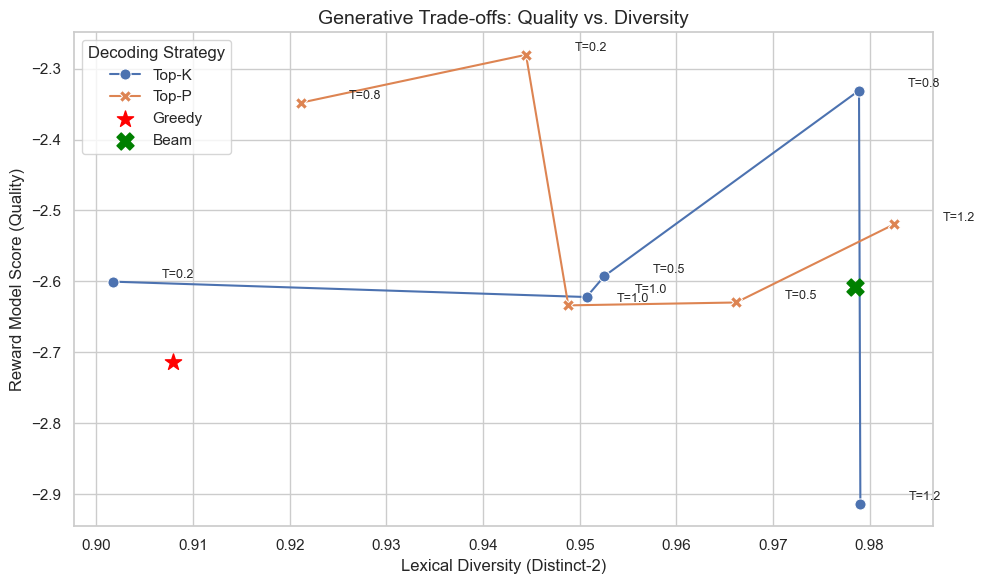

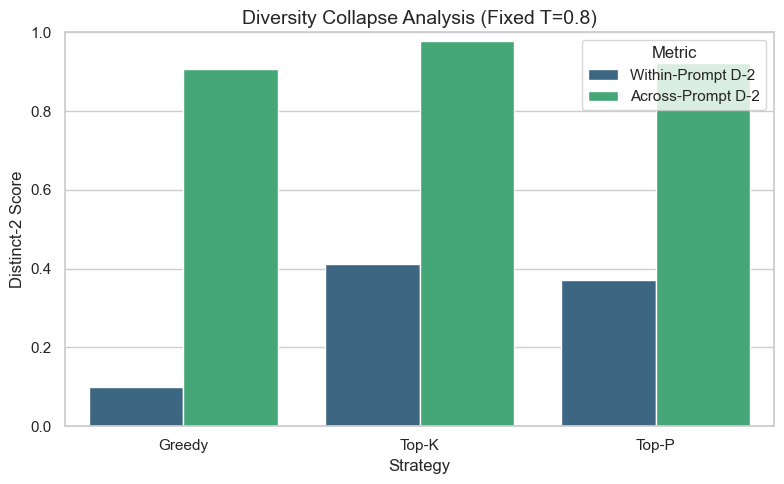

In [10]:
# Setup Plot Style
sns.set_theme(style="whitegrid")

# --- Plot 1: Quality-Diversity Frontier ---
plt.figure(figsize=(10, 6))

# Plot Stochastic lines
sns.lineplot(data=df_results[df_results["Strategy"].isin(["Top-K", "Top-P"])], 
             x="Distinct-2", y="Quality", hue="Strategy", 
             markers=True, dashes=False, style="Strategy", markersize=8)

# Plot Deterministic Points
greedy_pt = df_results[df_results["Strategy"]=="Greedy"]
beam_pt = df_results[df_results["Strategy"]=="Beam"]

plt.scatter(greedy_pt["Distinct-2"], greedy_pt["Quality"], color='red', s=150, label='Greedy', zorder=5, marker='*')
plt.scatter(beam_pt["Distinct-2"], beam_pt["Quality"], color='green', s=150, label='Beam', zorder=5, marker='X')

# Annotate Temperatures
for i, row in df_results.iterrows():
    if row["Strategy"] in ["Top-K", "Top-P"]:
        plt.text(row["Distinct-2"]+0.005, row["Quality"]+0.005, f"T={row['Temp']}", fontsize=9)

plt.title("Generative Trade-offs: Quality vs. Diversity", fontsize=14)
plt.xlabel("Lexical Diversity (Distinct-2)", fontsize=12)
plt.ylabel("Reward Model Score (Quality)", fontsize=12)
plt.legend(title="Decoding Strategy")
plt.tight_layout()
plt.savefig("tradeoff_analysis.png")
plt.show()

# --- Plot 2: Diversity Comparison ---
plt.figure(figsize=(8, 5))
df_div_melt = df_diversity.melt(id_vars="Strategy", var_name="Metric", value_name="Score")
sns.barplot(data=df_div_melt, x="Strategy", y="Score", hue="Metric", palette="viridis")

plt.title(f"Diversity Collapse Analysis (Fixed T={fixed_temp})", fontsize=14)
plt.ylabel("Distinct-2 Score", fontsize=12)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig("diversity_collapse.png")
plt.show()